In [97]:
import numpy as np
import matplotlib.pyplot as plt
from QPGC import QPGenericConstraints

We want to solve the problem:

$$
\begin{aligned}
\max_{x} \quad
& \sum_{i=1}^m x_i
\;-\;
\frac{1}{2}x^T G x \\
\text{s.t.} \quad
& \sum_{i=1}^m y_i x_i = 0 \\
& 0 \le x_i \le K
\end{aligned}
$$

where $x \in \mathbb{R}^n$ is the lagrange multiplier for each point of the dataset and $ G = Y X^T X Y$.
 

This is equivalent to the problem

$$
\min_{x} - \sum_{i=1}^m x_i + \frac{1}{2}x^T G x  = g^T x + \frac{1}{2}x^T G x  
$$

where $g \in \mathbb{R}^m, g = (-1, \dots, -1)$

And we can turn the equality constraints into

$$
A^Tx = b,  
$$

Where $A = y$ and $b = 0$. We can turn the inequality constraints into

$$
x_i \ge 0, \qquad -x_i \ge -K.
$$

both inequallities can be expressed as

$$
\begin{bmatrix}
I \\
- I
\end{bmatrix} x
\ge
\begin{bmatrix}
0 \\
- K\mathbf{1}
\end{bmatrix}.
$$

Where $I$ is the identity matrix of range $n$. Thus, if we define

$$
C =
\begin{bmatrix}
I & -I
\end{bmatrix},
\qquad

\qquad
d =
\begin{bmatrix}
\underbrace{0, \; 0, \; \dots, \; 0}_{n \text{ times}},
\;
\underbrace{-K, \; -K, \; \dots, \; -K}_{n \text{ times}}
\end{bmatrix}^T


$$

The problem can be expressed appliying all changes as

$$
\begin{aligned}
\min_{x} \quad
& \frac{1}{2} x^T G x + g^T x \\
\text{s.t.} \quad
& A^T x = b, \\
& C^T x \ge d
\end{aligned}
$$



### The role of $K$

In the primal problem, the parameter $K$ controls the penalty on margin violations:

$$
\min \frac{1}{2}\|w\|^2 + K \sum_i \xi_i.
$$

- Large $K$: strong penalty for violations, smaller margin, risk of overfitting  
- Small $K$: weaker penalty, wider margin, more tolerance to misclassification  








In [98]:
### Main functions ###

def create_dataset(m1, s1, m2, s2, n_samples=100, seed=None):
    """
    Create a binary classification dataset with two classes sampled from 
    multivariate normal distributions.
    
    Parameters
    ----------
    m1 : array-like
        Mean vector for class 1
    s1 : array-like
        Covariance matrix for class 1
    m2 : array-like
        Mean vector for class 2
    s2 : array-like
        Covariance matrix for class 2
    n_samples : int, optional
        Number of samples per class (default: 100)
    seed : int, optional
        Random seed for reproducibility (default: None)
    
    Returns
    -------
    X : ndarray of shape (2*n_samples, 2)
        Feature matrix with all data points
    y : ndarray of shape (2*n_samples,)
        Labels: +1 for class 1, -1 for class 2
    """
    if seed is not None:
        np.random.seed(seed)
    X1 = np.random.multivariate_normal(m1, s1, n_samples)
    y1 = np.ones(n_samples)
    X2 = np.random.multivariate_normal(m2, s2, n_samples)
    y2 = -np.ones(n_samples)
    X = np.vstack([X1, X2])
    y = np.concatenate([y1, y2])
    return X, y

def SVM_hyperplane(X, y, K=1.0, print_matrices=False):
    """
    Train an SVM using QPGenericConstraints with regularization parameter K.
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Feature matrix.
    y : ndarray of shape (n_samples,)
        Labels (+1 or -1).
    K : float
        Regularization parameter (C in soft-margin SVM).
    print_matrices : bool, optional
        If True, print the matrices used in the QP formulation.
        
    Returns
    -------
    w : ndarray
        Weight vector of the separating hyperplane.
    b : float
        Bias term.
    alphas : ndarray
        Lagrange multipliers.
    """
    n = X.shape[0]
    p = 1
    m = 2 * n

    # Matrices for QP initialized as explained in the last cell.
    A = y.reshape(n, p)
    b_vec = np.zeros(p)
    C = np.concatenate((np.eye(n), -np.eye(n)), axis=1)
    d = np.concatenate((np.zeros(n), -K * np.ones(n)))
    Y = np.diag(y)
    G = Y @ X @ X.T @ Y
    g = -np.ones(n)

    if print_matrices:
        print("X")
        print(X.shape)
        print(X)
        print("A")
        print(A.shape)
        print(A)
        print("b")
        print(b_vec.shape)
        print(b_vec)
        print("C")
        print(C.shape)
        print(C)
        print("d")
        print(d.shape)
        print(d)
        print("Y")
        print(Y.shape)
        print(Y)
        print("G")
        print(G.shape)
        print(G)
        print("g")
        print(g.shape)
        print(g) 

    # Solve QP
    alphas = QPGenericConstraints(G, g, A, C, b_vec, d)
    # Compute w and b
    w = (alphas * y) @ X
    sv = (alphas > 1e-5)
    b = np.mean(y[sv] - X[sv] @ w)
    return w, b, alphas

help(QPGenericConstraints)

Help on function QPGenericConstraints in module QPGC:

QPGenericConstraints(G, g, A, C, b, d)
    Convex optimization problem with equality and inequality constraints:
     
               min f(x)=1/2 x^T G X + g^T x     s.t.   A^T x = b i C^T x >= d
    
    Call it with:
    
    x = QPGenericConstrains(G, g, A, C, b, d)
    
    Notation:
    
    n = number of variables
    p = number of equality constants
    m = number of inequality constants
     
    Dimensions:   G -> n x n
                  g -> n x 1
                  A -> n x p
                  C -> n x m
                  b -> p x 1  
                  d -> m x 1



In [99]:
### Plotting functions ###

def plot_dataset(X, y, ax=None, title="Classification Dataset"):
    """
    Plot the dataset with different colors and shapes for each class.
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, 2)
        Feature matrix
    y : ndarray of shape (n_samples,)
        Labels: +1 for class 1, -1 for class 2
    ax : matplotlib.axes.Axes, optional
        Axes to plot on (default: creates new figure)
    title : str, optional
        Title for the plot (default: "Classification Dataset")
    
    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes with the plot
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    mask1 = y == 1
    ax.scatter(X[mask1, 0], X[mask1, 1], c='blue', marker='o', s=50, alpha=0.7, label='Class +1', edgecolors='darkblue')
    mask2 = y == -1
    ax.scatter(X[mask2, 0], X[mask2, 1], c='red', marker='s', s=50, alpha=0.7, label='Class -1', edgecolors='darkred')
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')
    return ax

def plot_svm_with_margin(X, y, w, b, ax=None, title="SVM with Margin"):
    """
    Plot a 2D dataset together with the SVM decision boundary and margin lines.

    The plot is automatically centered on the data points, and the decision
    boundary along with its margins is drawn to span the full visible plot
    area for consistent scaling.

    Parameters
    ----------
    X : ndarray of shape (n_samples, 2)
        Input feature matrix containing 2D points.
    y : ndarray of shape (n_samples,)
        Class labels for each sample, expected to be +1 or -1.
    w : ndarray of shape (2,)
        Weight vector defining the SVM separating hyperplane.
    b : float
        Bias (intercept) term of the separating hyperplane.
    ax : matplotlib.axes.Axes, optional
        Existing matplotlib axes to plot on. If None, a new figure and axes
        are created.
    title : str, optional
        Title displayed at the top of the plot.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The matplotlib axes object containing the plot.
    """
     
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    plot_dataset(X, y, ax=ax)

    # ---- Compute data-based limits with padding ----
    pad = 0.15
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()

    x_range = x_max - x_min
    y_range = y_max - y_min

    x_min -= pad * x_range
    x_max += pad * x_range
    y_min -= pad * y_range
    y_max += pad * y_range

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # ---- Plot hyperplane and margins across full axes ----
    if abs(w[1]) > 1e-8:
        xx = np.array([x_min, x_max])

        # Decision boundary
        yy = (-w[0] * xx - b) / w[1]
        ax.plot(xx, yy, 'k-', linewidth=2, label='SVM hyperplane')

        # Margins
        yy_p = (-w[0] * xx - b + 1) / w[1]
        yy_m = (-w[0] * xx - b - 1) / w[1]

        ax.plot(xx, yy_p, 'b--', linewidth=2, label='Margin +1')
        ax.plot(xx, yy_m, 'r-.', linewidth=2, label='Margin -1')

    # ---- Improve visual scaling ----
    ax.set_aspect('equal', adjustable='box')  # prevents distortion
    ax.margins(0.05)                          # small internal padding
    ax.legend()
    ax.set_title(title)

    return ax




# Create and Visualize the Dataset

### Dataset Parameters

Define the mean and covariance matrices for both classes.

In [100]:
# Class 1 parameters
m1 = [0., 0.]
s1 = [[1, -0.9], [-0.9, 1]]

# Class 2 parameters - Separable dataset
m2_separable = [3., 6.]
s2_separable = [[1, 0], [0, 1]]

# Class 2 parameters - Non-separable dataset 
m2_non_separable = [1., 2.]
s2_non_separable = [[1, 0], [0, 1]]

Separable dataset created with 200 samples
Class +1: 100 samples
Class -1: 100 samples


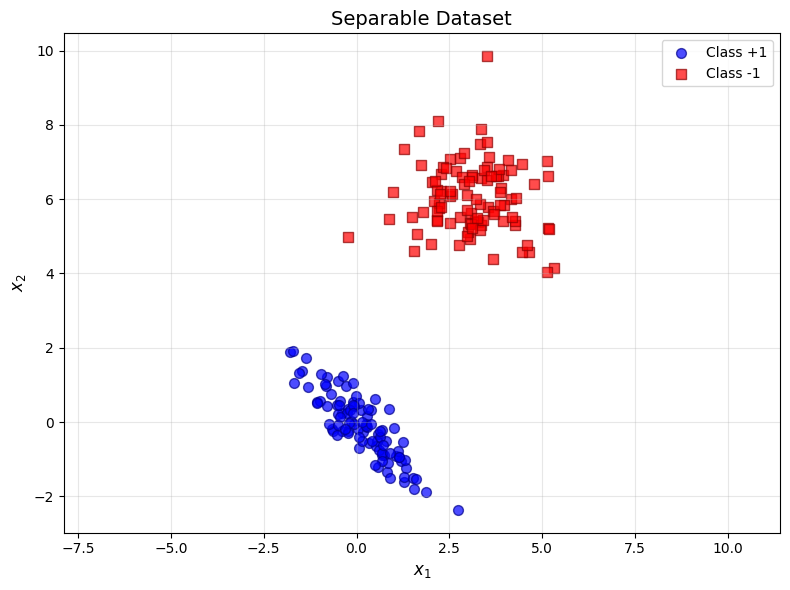

Non separable dataset created with 200 samples
Class +1: 100 samples
Class -1: 100 samples


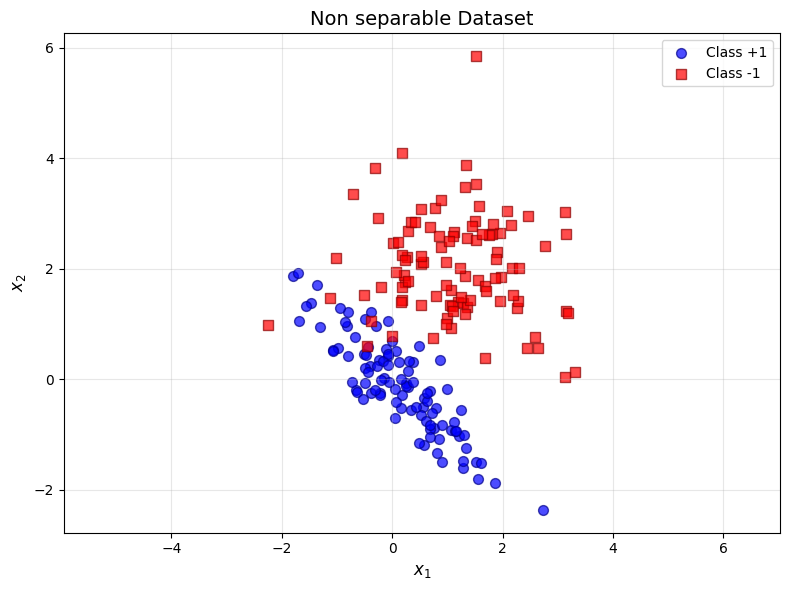

In [101]:
# Create the separable dataset
X_sep, y_sep = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)
print(f"Separable dataset created with {len(y_sep)} samples")
print(f"Class +1: {np.sum(y_sep == 1)} samples")
print(f"Class -1: {np.sum(y_sep == -1)} samples")

# Plot the dataset
plot_dataset(X_sep, y_sep, title="Separable Dataset")
plt.tight_layout()
plt.show()

# Create the non-separable dataset
X_non_sep, y_non_sep = create_dataset(m1, s1, m2_non_separable, s2_non_separable, n_samples=100, seed=42)
print(f"Non separable dataset created with {len(y_non_sep)} samples")
print(f"Class +1: {np.sum(y_non_sep == 1)} samples")
print(f"Class -1: {np.sum(y_non_sep == -1)} samples")

# Plot the dataset
plot_dataset(X_non_sep, y_non_sep, title="Non separable Dataset")
plt.tight_layout()
plt.show()

# Experiments

## Experiment 1

We can see that when choosing 2 points for each class and K=1, the algorithm correctly separates both classes, leaving all points in the correct side of the margin.

w: [-0.18911393 -0.29661133]
b: 1.233280404617954


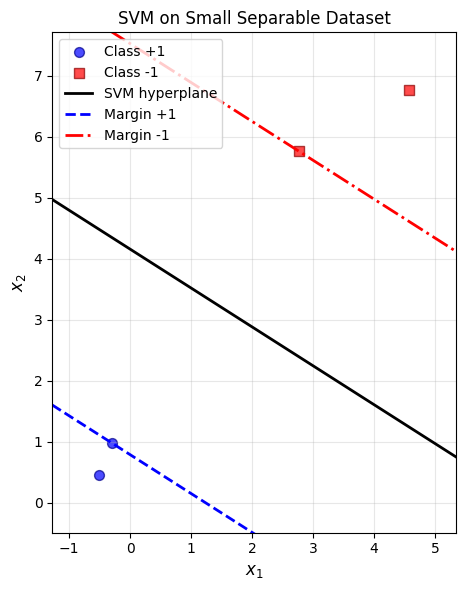

In [102]:
# Experiment 1. Separable dataset with 2 samples per class
X_small, y_small = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=2, seed=42)
w, b, _ = SVM_hyperplane(X_small, y_small, K=1.0)
print("w:", w)
print("b:", b)
plot_svm_with_margin(X_small, y_small, w, b, title="SVM on Small Separable Dataset")
plt.tight_layout()
plt.show()


## Experiment 2

When we change the value of $K$ across a range of several values, we can notice that with small $K$ values, the confidence margin becomes wider because we are increasing the tolerance for violations of the margin. If we set the $K$ parameter to 1, all the points are outside the margin or right in the margin. When we weep increasing the $K$ value, the margin gets narrower because this means that we are reducing our tolerance to missclassified points. When we reach too high values, the numbers of the matrices become too big for the computer to handle from $K = 1e6$. 

K=0.001
w: [-0.1525471  -0.24928383]
b: 0.9341680449702204


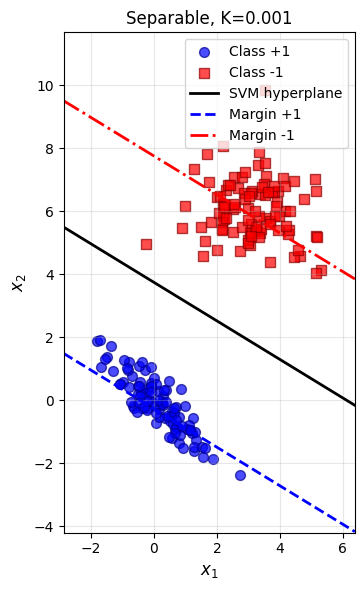

K=0.01
w: [-0.20366247 -0.33877814]
b: 1.1754969607927677


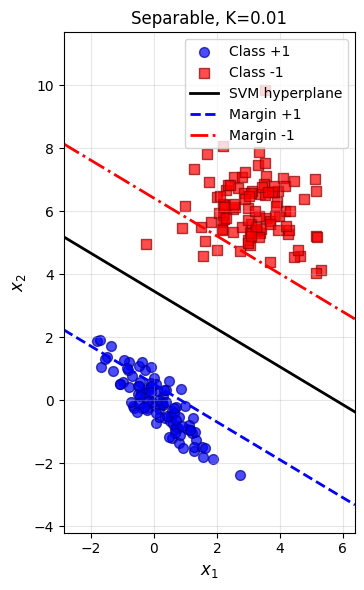

K=0.1
w: [-0.23536804 -0.45913213]
b: 1.4139718625003859


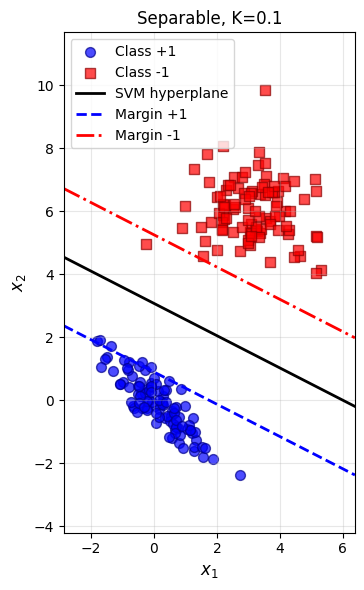

K=1
w: [-0.25645704 -0.53182677]
b: 1.5842891321274823


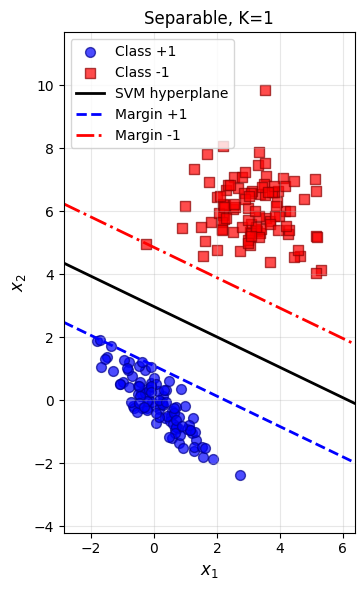

K=10
w: [-0.25601681 -0.53205559]
b: 1.5614494631661382


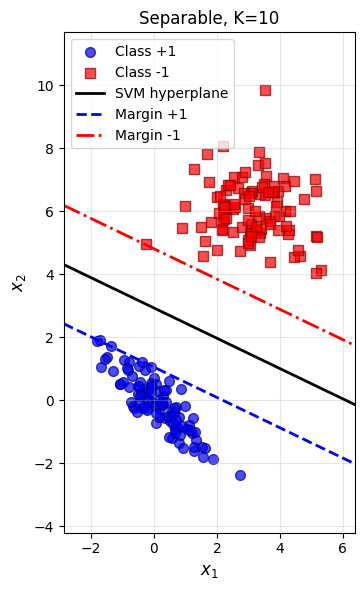

K=100
w: [-0.23986723 -0.60034395]
b: 2.172162099856027


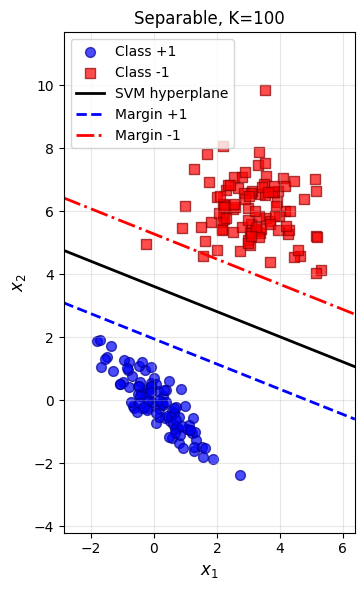

K=1000
w: [-0.2358815  -0.59889401]
b: 2.1613830959806877


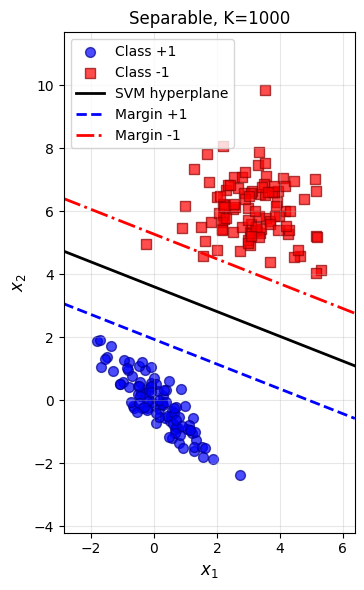

K=10000
w: [-0.24418639 -0.55807518]
b: 2.0536718420711844


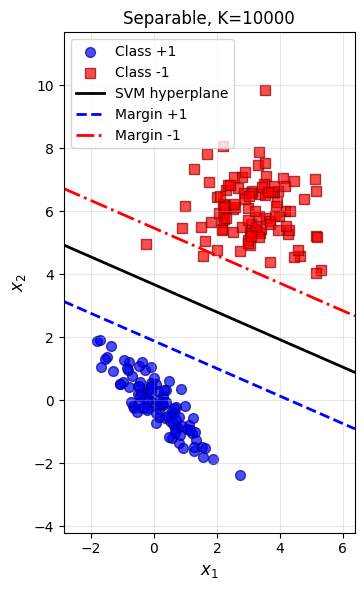

K=100000.0
w: [-0.25311408 -0.53381382]
b: 1.3227576648437076


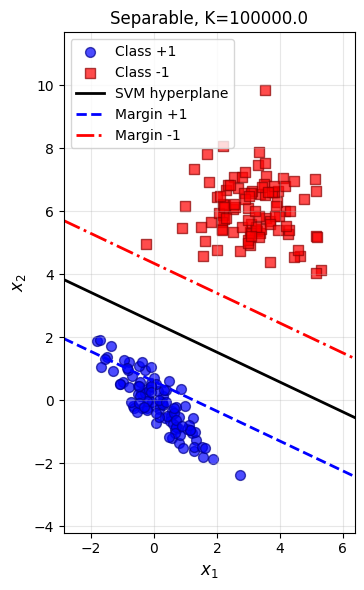

K=1000000.0
w: [nan nan]
b: nan


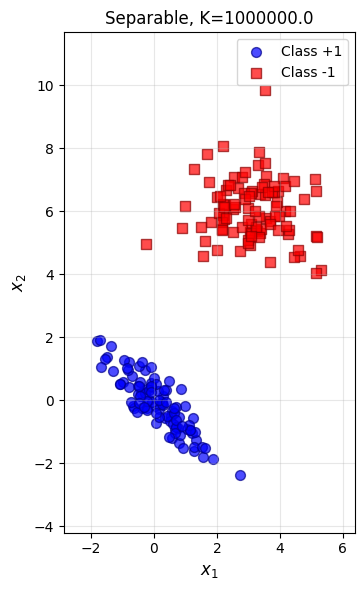

K=1000000000000.0
w: [nan nan]
b: nan


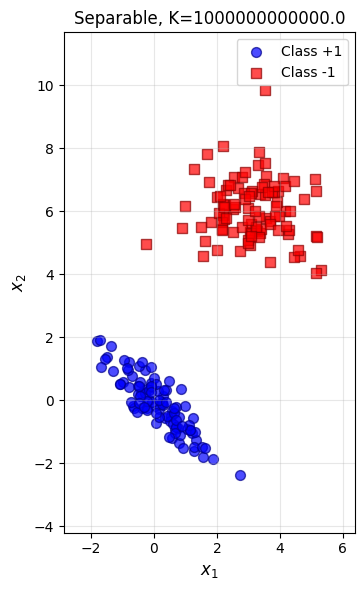

In [103]:
# Experiment 2. Separable dataset, 100 samples per class, multiple K values
K_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 1e5, 1e6, 1e12]
for K in K_values:
    X_sep, y_sep = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)
    w_sep, b_sep, _ = SVM_hyperplane(X_sep, y_sep, K=K)
    print(f"K={K}")
    print("w:", w_sep)
    print("b:", b_sep)
    plot_svm_with_margin(X_sep, y_sep, w_sep, b_sep, title=f"Separable, K={K}")
    plt.tight_layout()
    plt.show()


## Experiment 3

Similarly as before, in this case, when we change the value of $K$ across a range of several values, we can notice that with small $K$ values, the confidence margin becomes wider because we are increasing the tolerance for violations of the margin. In the case of $K = 0.001$,  most of the points are outside the margin, because we can not classify them with enough confidence for that $K$ parameter. If we set the $K$ parameter to 1, we get a good balance of missclassified points outside of the margin. When we weep increasing the $K$ value, the margin gets narrower because this means that we are reducing our tolerance to missclassified points. When we reach values that are too high, the method stops converging in a correct separation line, missclassifing a lot of the points. 

K=0.001
w: [-0.10080019 -0.21485143]
b: 0.2711643864285309


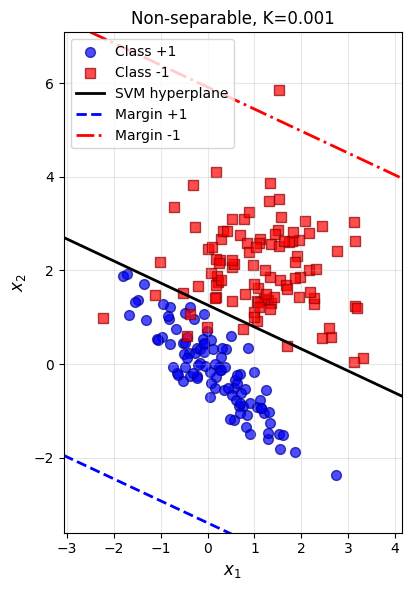

K=0.01
w: [-0.46529077 -0.65870245]
b: 0.7804556059562732


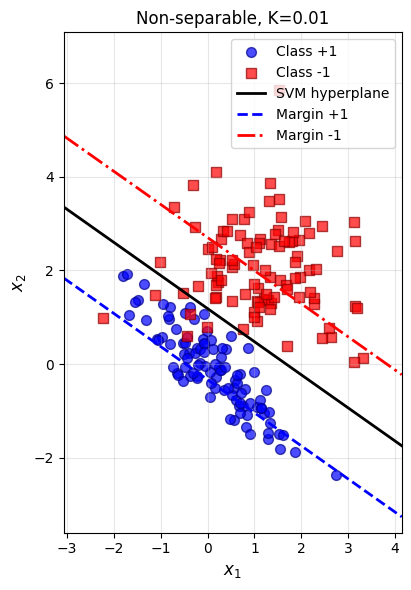

K=0.1
w: [-0.85217644 -1.1593091 ]
b: 1.1913063079291102


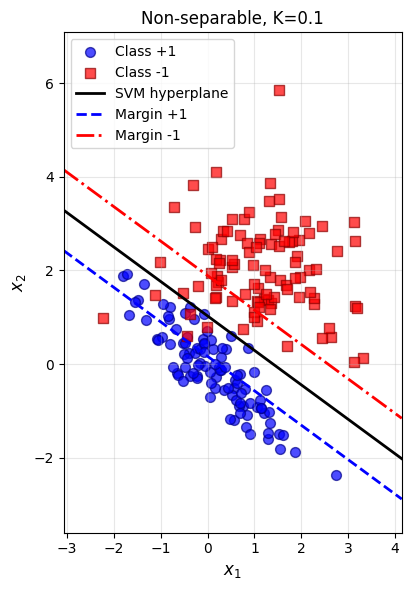

K=1
w: [-1.28731185 -1.76551683]
b: 1.6097735998425602


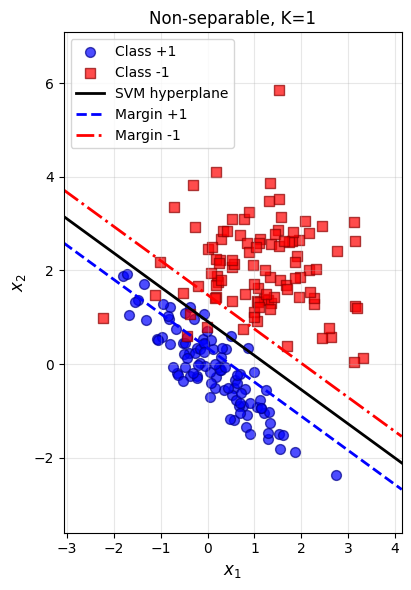

K=10
w: [-1.61387899 -2.43036997]
b: 2.114512370363481


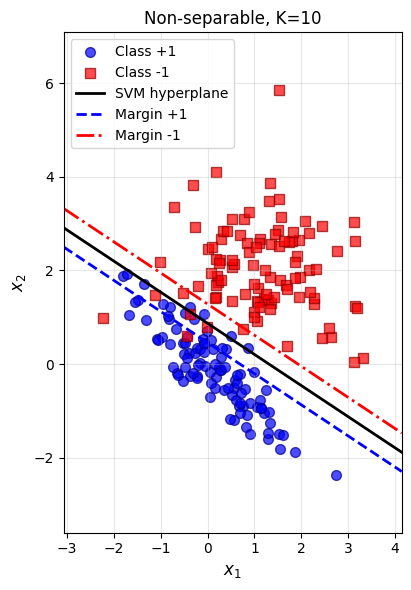

K=100
w: [-1.61325806 -2.43353943]
b: 2.1182120387200607


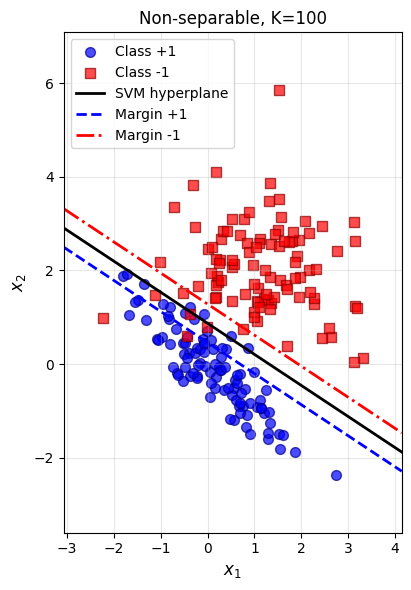

K=1000
w: [-1.61325806 -2.43353943]
b: 2.1182120387220156


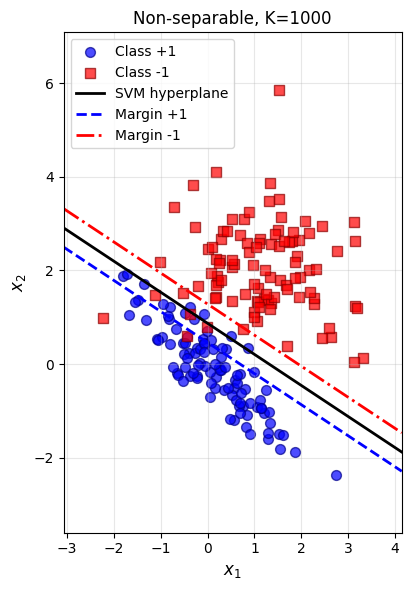

K=10000
w: [-1.61325806 -2.43353943]
b: 2.1182120387628087


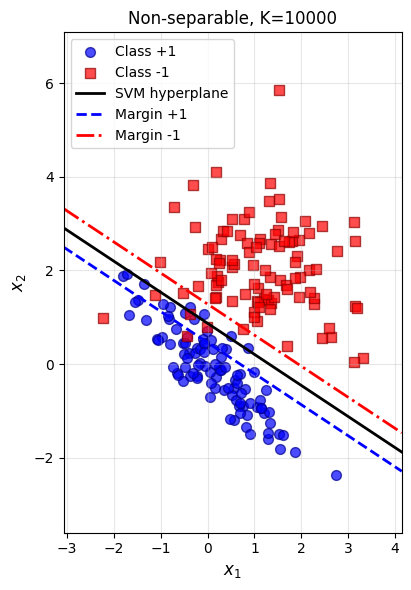

K=100000.0
w: [-1.61325806 -2.43353943]
b: 2.1182120390623043


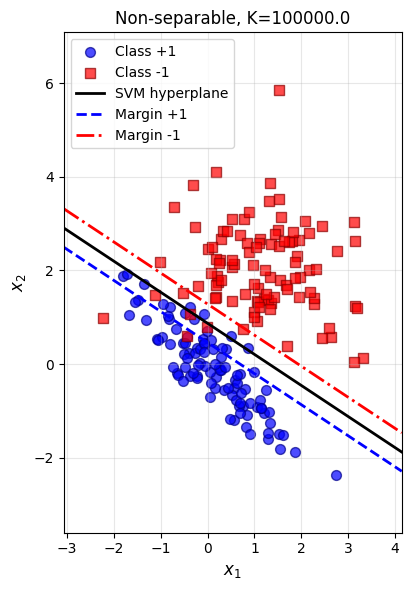

K=1000000.0
w: [-1.61325806 -2.43353944]
b: 2.1182120413265713


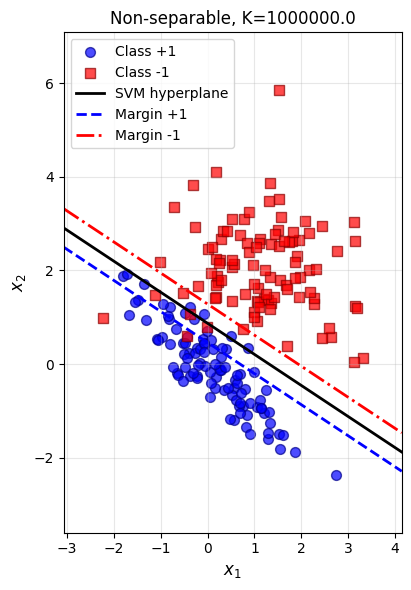

K=1000000000000.0
w: [-20597.8056489     704.73106232]
b: 2668.878043002846


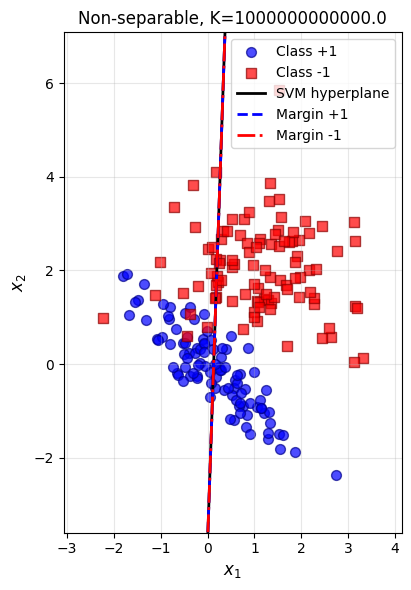

In [104]:
# Experiment 3: Non-separable dataset, 100 samples per class, multiple K values
K_values_nonsep = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 1e5, 1e6, 1e12]
for K in K_values_nonsep:
    X_nonsep, y_nonsep = create_dataset(m1, s1, m2_non_separable, s2_non_separable, n_samples=100, seed=42)
    w_nonsep, b_nonsep, _ = SVM_hyperplane(X_nonsep, y_nonsep, K=K)
    print(f"K={K}")
    print("w:", w_nonsep)
    print("b:", b_nonsep)
    plot_svm_with_margin(X_nonsep, y_nonsep, w_nonsep, b_nonsep, title=f"Non-separable, K={K}")
    plt.tight_layout()
    plt.show()
